# Continual-Learning Validation

This notebook performs evaluation only. It restores a continual-learning checkpoint containing the policy, trajectory encoder, and residual-dynamics network; collects fresh held-out disturbed rollouts; and evaluates:

1. policy tracking over the fresh rollouts;
2. recursive five-second open-loop residual dynamics using the recorded actions and initial simulator states;
3. the encoder latent space using wind labels only for visualization.

No parameters are updated and no validation data are used for training.


In [1]:
import gc
import os
from pathlib import Path

import numpy as np

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation
from matplotlib import pyplot as plt
from orbax.checkpoint import PyTreeCheckpointer

from lotf import LOTF_PATH
from lotf.envs import HoveringStateEnv
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import (
    LatentConditionedResidualDynamics,
    MLP,
    RecurrentTrajectoryEncoder,
)
from lotf.objects import Quadrotor

%matplotlib inline


## 1. Validation configuration

Set checkpoint_round to an integer to evaluate a specific saved round. Leaving it as None selects the latest available checkpoint.


In [2]:
seed = 2026
master_key = jax.random.key(seed)


def experiment_key(stream_id):
    return jax.random.fold_in(master_key, stream_id)


checkpoint_round = None
continual_checkpoint_root = Path(os.path.abspath(os.path.join(
    LOTF_PATH,
    "..",
    "checkpoints",
    "continual_vnd",
    "state_hovering_full",
)))

validation_num_rollouts = 32
open_loop_validation_time = 5.0
last_policy_window_seconds = 3.0
max_open_loop_trajectory_plots = 16
encoder_evaluation_batch_size = 512

context_length = 20
latent_dim = 12
state_action_dim = 14
residual_dim = 6
sim_dt = 0.02
control_delay = 0.04
hover_target = jnp.asarray([1.5, 0.0, 1.5], dtype=jnp.float32)

open_loop_horizon = int(round(open_loop_validation_time / sim_dt))
validation_num_steps = context_length + open_loop_horizon
validation_duration = validation_num_steps * sim_dt

assert context_length == 20
assert state_action_dim == 14
assert residual_dim == 6
assert validation_num_rollouts > 0
assert open_loop_horizon > 0
assert last_policy_window_seconds > 0
assert last_policy_window_seconds <= validation_duration

print(f"Fresh validation rollouts: {validation_num_rollouts}")
print(
    f"Collected duration: {validation_duration:.2f} s "
    f"({validation_num_steps} steps)"
)
print(f"Residual open-loop horizon: {open_loop_validation_time:.2f} s")


Fresh validation rollouts: 32
Collected duration: 5.40 s (270 steps)
Residual open-loop horizon: 5.00 s


## 2. Recreate the environments and model modules

The disturbed environment generates the held-out trajectories. The nominal environment uses the same simulator configuration and control delay, but does not apply hidden wind; it is used only for open-loop residual evaluation.


In [3]:
nominal_dynamics_configuration = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
quadrotor = Quadrotor.from_name(
    "example_quad", nominal_dynamics_configuration
)

validation_env = HoveringStateEnv(
    max_steps_in_episode=validation_num_steps,
    dt=sim_dt,
    delay=control_delay,
    quad_obj=quadrotor,
    margin=0.5,
    hover_target=hover_target,
    apply_hidden_acceleration=True,
)
validation_env = MinMaxObservationWrapper(validation_env)

nominal_env = HoveringStateEnv(
    max_steps_in_episode=validation_num_steps,
    dt=sim_dt,
    delay=control_delay,
    quad_obj=quadrotor,
    margin=0.5,
    hover_target=hover_target,
    apply_hidden_acceleration=False,
)

obs_dim = validation_env.observation_space.shape[0]
action_dim = validation_env.action_space.shape[0]
dummy_residual_params = {}

trajectory_encoder = RecurrentTrajectoryEncoder(
    state_action_dim=state_action_dim,
    context_length=context_length,
    latent_dim=latent_dim,
    projection_dim=128,
    hidden_dim=128,
)
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=state_action_dim,
    latent_dim=latent_dim,
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=False,
)
latent_policy_net = MLP(
    [obs_dim + latent_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=validation_env.hovering_action,
)

print(f"Observation dimension: {obs_dim}")
print(f"Action dimension:      {action_dim}")
print(f"Control delay:         {control_delay:.3f} s")


Observation dimension: 27
Action dimension:      4
Control delay:         0.040 s


## 3. Restore the continual checkpoint

Only the final parameter trees and normalization statistics are retained after restoration. Optimizer states are discarded from memory because this notebook never trains.


In [4]:
checkpoint_candidates = sorted(
    (
        path for path in continual_checkpoint_root.glob("round_*")
        if path.is_dir()
    ),
    key=lambda path: int(path.name.split("_")[-1]),
)
if not checkpoint_candidates:
    raise FileNotFoundError(
        f"No continual checkpoints found under {continual_checkpoint_root}"
    )

if checkpoint_round is None:
    continual_checkpoint_path = checkpoint_candidates[-1]
else:
    continual_checkpoint_path = (
        continual_checkpoint_root / f"round_{checkpoint_round:04d}"
    )
    if not continual_checkpoint_path.is_dir():
        raise FileNotFoundError(
            f"Checkpoint does not exist: {continual_checkpoint_path}"
        )

restored_checkpoint = PyTreeCheckpointer().restore(
    str(continual_checkpoint_path)
)


def extract_params(saved_train_state):
    if hasattr(saved_train_state, "params"):
        return saved_train_state.params
    if isinstance(saved_train_state, dict) and "params" in saved_train_state:
        return saved_train_state["params"]
    raise TypeError(
        "Expected a restored TrainState or a dictionary containing 'params'"
    )


restored_joint_params = extract_params(
    restored_checkpoint["joint_train_state"]
)
policy_params = extract_params(restored_checkpoint["policy_train_state"])
input_mean = restored_checkpoint["input_mean"]
input_std = restored_checkpoint["input_std"]
residual_target_mean = restored_checkpoint["residual_target_mean"]
residual_target_std = restored_checkpoint["residual_target_std"]
completed_rounds = int(jax.device_get(
    restored_checkpoint["completed_rounds"]
))


def tree_is_finite(tree):
    return all(
        bool(jax.device_get(jnp.all(jnp.isfinite(leaf))))
        for leaf in jax.tree.leaves(tree)
    )


if set(restored_joint_params) != {"encoder", "residual", "decoder"}:
    raise ValueError(
        "The joint checkpoint must contain encoder, residual, and decoder "
        "parameter groups"
    )
if not tree_is_finite(policy_params):
    raise ValueError(
        "The restored policy contains NaN or Inf parameters. Select a clean "
        "checkpoint rather than a checkpoint saved after policy corruption."
    )
joint_params = {
    "encoder": restored_joint_params["encoder"],
    "residual": restored_joint_params["residual"],
}
if not tree_is_finite(joint_params):
    raise ValueError("The restored encoder or residual parameters are non-finite")

# Release the unused decoder and both optimizer states held by the restored
# checkpoint. Validation keeps only policy, encoder, and residual params.
del restored_joint_params, restored_checkpoint
gc.collect()

dummy_policy_input = jnp.zeros(
    (1, obs_dim + latent_dim), dtype=jnp.float32
)
dummy_policy_action = latent_policy_net.apply(
    policy_params, dummy_policy_input
)
assert dummy_policy_action.shape == (1, action_dim)

print(f"Loaded checkpoint: {continual_checkpoint_path}")
print(f"Completed continual rounds: {completed_rounds}")
print(f"Loaded parameter groups: {tuple(joint_params.keys())}")
print(f"Policy output shape check: {dummy_policy_action.shape}")


/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Loaded checkpoint: /home/dimitria/PhD_codes/learning_on_the_fly/checkpoints/continual_vnd/state_hovering_full/round_0550
Completed continual rounds: 550
Loaded parameter groups: ('encoder', 'residual')
Policy output shape check: (1, 4)


## 4. State representation and fresh rollout collection

The deployed policy receives a rolling encoder context after the first 20 transitions. Before the context is full, it receives a zero latent, matching continual training. No validation action excitation is added.


In [5]:
def state_vector_from_env_state(env_state):
    quaternion_xyzw = Rotation.from_matrix(
        env_state.quadrotor_state.R
    ).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]],
        axis=-1,
    )
    return jnp.concatenate([
        env_state.quadrotor_state.p,
        quaternion_wxyz,
        env_state.quadrotor_state.v,
    ], axis=-1)


def normalize_state_actions(raw_state_actions):
    normalized = (raw_state_actions - input_mean) / input_std
    normalized = normalized.at[..., 0:3].set(
        jnp.clip(normalized[..., 0:3], -5.0, 5.0)
    )
    normalized = normalized.at[..., 7:10].set(
        jnp.clip(normalized[..., 7:10], -5.0, 5.0)
    )
    return normalized


@jax.jit
def collect_validation_rollouts(collection_key):
    key_reset, key_scan = jax.random.split(collection_key)
    reset_keys = jax.random.split(key_reset, validation_num_rollouts)
    initial_states, initial_observations = jax.vmap(
        validation_env.reset
    )(reset_keys)
    initial_contexts = jnp.zeros(
        (validation_num_rollouts, context_length, state_action_dim),
        dtype=jnp.float32,
    )

    def collection_step(carry, step_key):
        env_states, observations, contexts, context_count = carry
        encoded_latents = trajectory_encoder.apply(
            joint_params["encoder"], contexts
        )
        policy_latents = jnp.where(
            context_count >= context_length,
            encoded_latents,
            jnp.zeros_like(encoded_latents),
        )
        policy_inputs = jnp.concatenate(
            [observations, policy_latents], axis=-1
        )
        actions = latent_policy_net.apply(policy_params, policy_inputs)
        actions = jnp.clip(
            actions,
            validation_env.action_space.low,
            validation_env.action_space.high,
        )

        environment_keys = jax.random.split(
            step_key, validation_num_rollouts
        )
        transitions = jax.vmap(
            lambda state, action, key: validation_env._step(
                state, action, dummy_residual_params, key
            )
        )(env_states, actions, environment_keys)

        raw_state_actions = jnp.concatenate(
            [state_vector_from_env_state(env_states), actions],
            axis=-1,
        )
        normalized_state_actions = normalize_state_actions(
            raw_state_actions
        )
        next_contexts = jnp.roll(contexts, shift=-1, axis=1)
        next_contexts = next_contexts.at[:, -1, :].set(
            normalized_state_actions
        )
        done = jnp.logical_or(
            transitions.terminated, transitions.truncated
        )
        outputs = (
            transitions.state,
            actions,
            done,
            environment_keys,
            policy_latents,
        )
        next_carry = (
            transitions.state,
            transitions.obs,
            next_contexts,
            context_count + 1,
        )
        return next_carry, outputs

    scan_keys = jax.random.split(key_scan, validation_num_steps)
    _, outputs = jax.lax.scan(
        collection_step,
        (
            initial_states,
            initial_observations,
            initial_contexts,
            jnp.asarray(0, dtype=jnp.int32),
        ),
        scan_keys,
    )
    successor_states, actions, done, step_keys, policy_latents = outputs
    time_major_states = jax.tree.map(
        lambda initial, successors: jnp.concatenate(
            [initial[None], successors], axis=0
        ),
        initial_states,
        successor_states,
    )
    rollout_states = jax.tree.map(
        lambda leaf: jnp.swapaxes(leaf, 0, 1),
        time_major_states,
    )
    return (
        rollout_states,
        jnp.swapaxes(actions, 0, 1),
        jnp.swapaxes(done, 0, 1),
        jnp.swapaxes(step_keys, 0, 1),
        jnp.swapaxes(policy_latents, 0, 1),
    )


In [6]:
(
    validation_states,
    validation_actions,
    validation_done,
    validation_step_keys,
    validation_policy_latents,
) = collect_validation_rollouts(experiment_key(100))
validation_states.quadrotor_state.p.block_until_ready()

validation_quad_states = validation_states.quadrotor_state
validation_state_vectors = state_vector_from_env_state(
    jax.tree.map(lambda leaf: leaf[:, :-1], validation_states)
)
validation_state_actions = jnp.concatenate(
    [validation_state_vectors, validation_actions], axis=-1
)
validation_normalized_state_actions = normalize_state_actions(
    validation_state_actions
)

# The transition that first terminates an episode remains valid. Anything
# after that terminal transition is masked.
validation_valid_transition = (
    jnp.cumsum(validation_done, axis=1) - validation_done
) == 0
validation_winds = validation_states.hidden_acceleration[:, 0, :]
assert bool(jnp.all(
    validation_states.hidden_acceleration
    == validation_states.hidden_acceleration[:, :1, :]
))

valid_steps_per_rollout = validation_valid_transition.sum(axis=1)
print("Fresh validation collection complete")
print(
    f"  valid steps per rollout: min={int(valid_steps_per_rollout.min())}, "
    f"mean={float(valid_steps_per_rollout.mean()):.1f}, "
    f"max={int(valid_steps_per_rollout.max())}"
)
print(f"  represented wind vectors: {jnp.unique(validation_winds, axis=0).shape[0]}")


Fresh validation collection complete
  valid steps per rollout: min=270, mean=270.0, max=270
  represented wind vectors: 17


## 5. Policy validation

The desired trajectory is the constant hover target. RMSE is computed separately for each rollout from Euclidean position error over valid samples in the final three seconds of the requested validation duration, then averaged across eligible rollouts.


Policy position RMSE in final 3.0 s: 4.768102e-02 +/- 2.072127e-02 m
Eligible rollouts in final window: 32/32


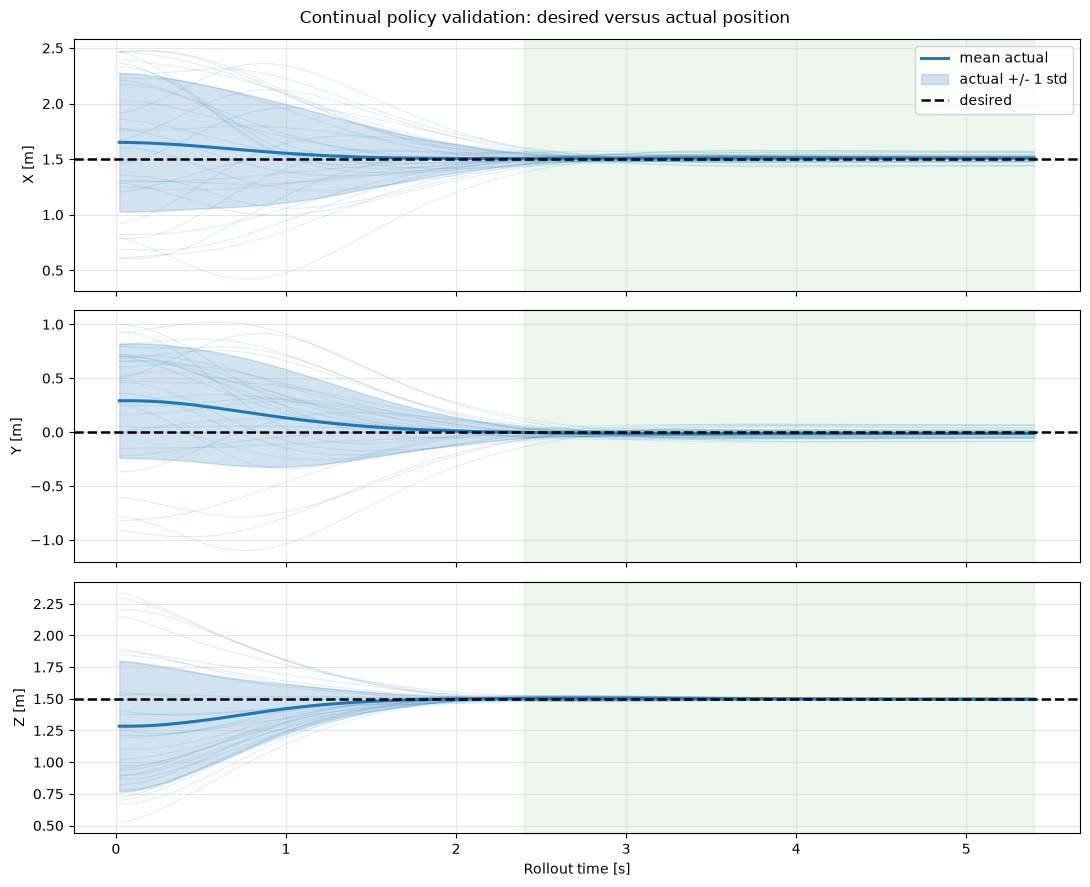

In [7]:
policy_time = sim_dt * (jnp.arange(validation_num_steps) + 1)
policy_positions = validation_quad_states.p[:, 1:]
policy_position_errors = jnp.linalg.norm(
    policy_positions - hover_target, axis=-1
)
policy_last_window_start = validation_duration - last_policy_window_seconds
policy_last_window = policy_time >= policy_last_window_start
policy_last_window_mask = (
    validation_valid_transition & policy_last_window[None, :]
)
policy_last_window_counts = policy_last_window_mask.sum(axis=1)
per_rollout_policy_rmse = jnp.where(
    policy_last_window_counts > 0,
    jnp.sqrt(
        jnp.sum(
            jnp.where(
                policy_last_window_mask,
                jnp.square(policy_position_errors),
                0.0,
            ),
            axis=1,
        )
        / jnp.maximum(policy_last_window_counts, 1)
    ),
    jnp.nan,
)

host_policy_rmse = np.asarray(jax.device_get(per_rollout_policy_rmse))
eligible_policy_rmse = host_policy_rmse[np.isfinite(host_policy_rmse)]
if eligible_policy_rmse.size:
    mean_policy_rmse = eligible_policy_rmse.mean()
    std_policy_rmse = eligible_policy_rmse.std()
else:
    mean_policy_rmse = np.nan
    std_policy_rmse = np.nan

print(
    f"Policy position RMSE in final {last_policy_window_seconds:.1f} s: "
    f"{mean_policy_rmse:.6e} +/- {std_policy_rmse:.6e} m"
)
print(
    f"Eligible rollouts in final window: "
    f"{eligible_policy_rmse.size}/{validation_num_rollouts}"
)

host_policy_time = np.asarray(jax.device_get(policy_time))
host_policy_positions = np.asarray(jax.device_get(policy_positions))
host_policy_valid = np.asarray(jax.device_get(
    validation_valid_transition
))
masked_policy_positions = np.where(
    host_policy_valid[..., None], host_policy_positions, np.nan
)
mean_policy_position = np.nanmean(masked_policy_positions, axis=0)
std_policy_position = np.nanstd(masked_policy_positions, axis=0)

coordinate_names = ("X", "Y", "Z")
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for coordinate, axis in enumerate(axes):
    for rollout_index in range(validation_num_rollouts):
        axis.plot(
            host_policy_time,
            masked_policy_positions[rollout_index, :, coordinate],
            color="C0",
            alpha=0.12,
            linewidth=0.8,
        )
    axis.plot(
        host_policy_time,
        mean_policy_position[:, coordinate],
        color="C0",
        linewidth=2.2,
        label="mean actual",
    )
    axis.fill_between(
        host_policy_time,
        mean_policy_position[:, coordinate]
        - std_policy_position[:, coordinate],
        mean_policy_position[:, coordinate]
        + std_policy_position[:, coordinate],
        color="C0",
        alpha=0.2,
        label="actual +/- 1 std" if coordinate == 0 else None,
    )
    axis.axhline(
        float(hover_target[coordinate]),
        color="black",
        linestyle="--",
        linewidth=1.8,
        label="desired",
    )
    axis.axvspan(
        policy_last_window_start,
        validation_duration,
        color="C2",
        alpha=0.08,
    )
    axis.set_ylabel(f"{coordinate_names[coordinate]} [m]")
    axis.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Rollout time [s]")
fig.suptitle(
    "Continual policy validation: desired versus actual position"
)
fig.tight_layout()
plt.show()


## 6. Five-second recursive open-loop residual-dynamics validation

One latent is inferred from the measured initial context and held fixed for each rollout. Starting from the exact measured simulator state at the end of that context, the nominal simulator recursively replays the recorded action sequence and original random keys. The learned physical position and velocity correction is applied after every nominal step. There is no teacher forcing.


In [8]:
open_loop_context_valid = validation_valid_transition[
    :, :context_length
].all(axis=1)
open_loop_available_steps = validation_valid_transition[
    :, context_length:context_length + open_loop_horizon
].sum(axis=1)
open_loop_eligible = (
    open_loop_context_valid & (open_loop_available_steps > 0)
)
if not bool(jnp.any(open_loop_eligible)):
    raise ValueError(
        "No validation rollout survived the 20-step encoder context. "
        "Residual open-loop validation cannot be performed."
    )

open_loop_rollout_indices = jnp.flatnonzero(open_loop_eligible)
open_loop_valid_mask = validation_valid_transition[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
open_loop_initial_states = jax.tree.map(
    lambda leaf: leaf[open_loop_rollout_indices, context_length],
    validation_states,
)
open_loop_initial_contexts = validation_normalized_state_actions[
    open_loop_rollout_indices, :context_length
]
open_loop_actions = validation_actions[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
open_loop_keys = validation_step_keys[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
open_loop_true_states = jax.tree.map(
    lambda leaf: leaf[
        open_loop_rollout_indices,
        context_length + 1:context_length + open_loop_horizon + 1,
    ],
    validation_quad_states,
)
open_loop_winds = validation_winds[open_loop_rollout_indices]
open_loop_time = sim_dt * (jnp.arange(open_loop_horizon) + 1)

print(f"Eligible open-loop rollouts: {open_loop_rollout_indices.shape[0]}")
print(
    f"Rollouts valid through {open_loop_validation_time:.1f} s: "
    f"{int(open_loop_valid_mask[:, -1].sum())}"
)


Eligible open-loop rollouts: 32
Rollouts valid through 5.0 s: 32


Mean open-loop position RMSE across rollouts: 2.771184e-02 +/- 1.691037e-02 m
Per-rollout cumulative Euclidean position dynamics error:
  rollout 00: valid_steps=250, wind=(+0.00, -2.00, +0.00) m/s^2, cumulative_error=1.301801e+00 m, RMSE=6.943360e-03 m
  rollout 01: valid_steps=250, wind=(+0.00, -1.00, +0.00) m/s^2, cumulative_error=1.440176e+00 m, RMSE=7.332219e-03 m
  rollout 02: valid_steps=250, wind=(+0.00, +0.00, +0.00) m/s^2, cumulative_error=6.079107e+00 m, RMSE=3.254852e-02 m
  rollout 03: valid_steps=250, wind=(-0.71, -0.71, +0.00) m/s^2, cumulative_error=5.034273e+00 m, RMSE=2.672968e-02 m
  rollout 04: valid_steps=250, wind=(-1.41, -1.41, +0.00) m/s^2, cumulative_error=2.154081e+00 m, RMSE=1.112773e-02 m
  rollout 05: valid_steps=250, wind=(-0.00, +1.00, +0.00) m/s^2, cumulative_error=6.258525e+00 m, RMSE=3.341033e-02 m
  rollout 06: valid_steps=250, wind=(+1.41, -1.41, +0.00) m/s^2, cumulative_error=4.873105e+00 m, RMSE=2.584259e-02 m
  rollout 07: valid_steps=250, wind=(-

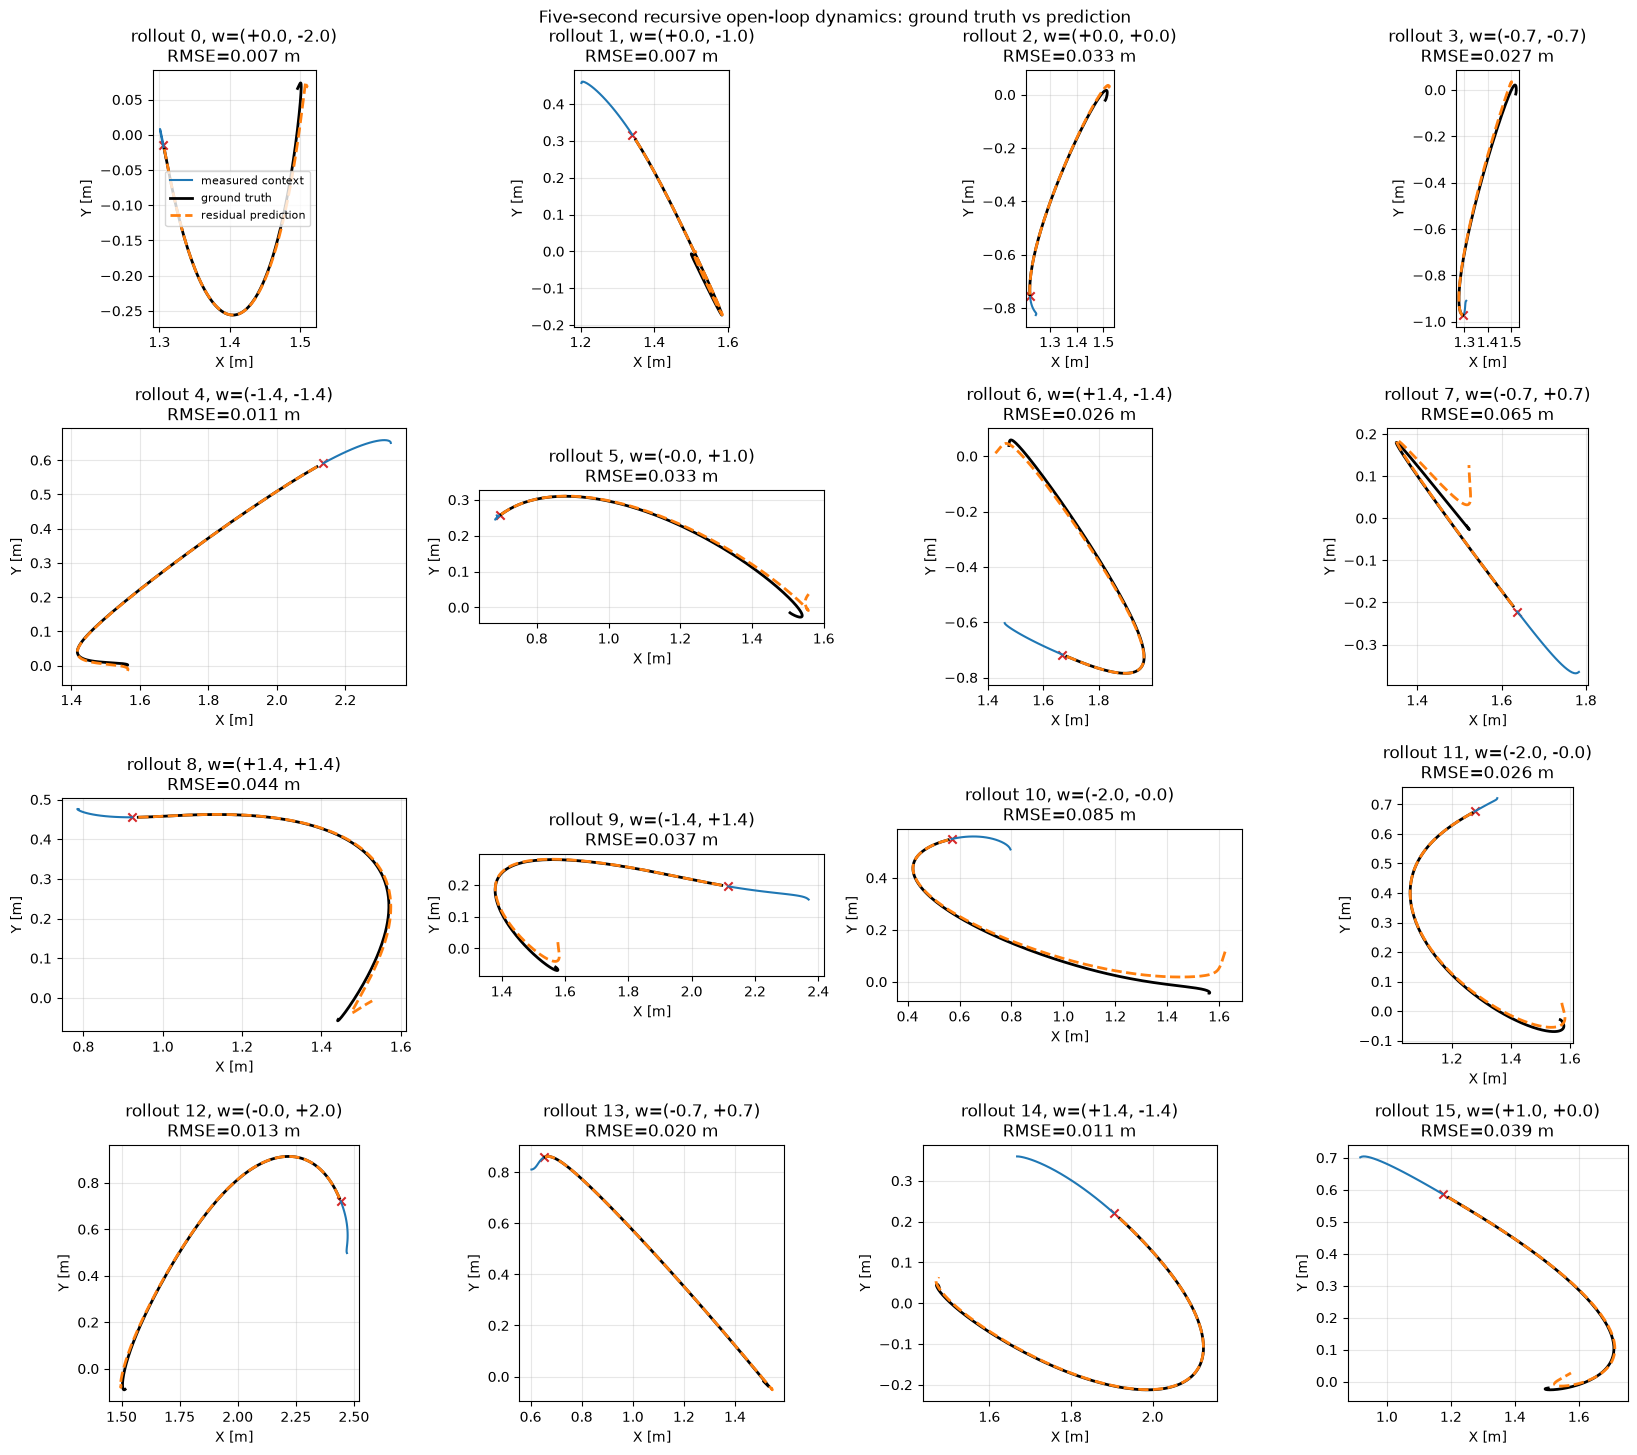

In [9]:
def learned_open_loop(
    initial_state, initial_context, action_sequence, step_keys
):
    fixed_latent = trajectory_encoder.apply(
        joint_params["encoder"], initial_context
    )

    def learned_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        raw_state_action = jnp.concatenate(
            [state_vector_from_env_state(predicted_state), action],
            axis=-1,
        )
        normalized_state_action = normalize_state_actions(
            raw_state_action
        )
        nominal_transition = nominal_env._step(
            predicted_state, action, dummy_residual_params, step_key
        )
        normalized_residual = residual_model.apply(
            joint_params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        physical_residual = (
            normalized_residual * residual_target_std
            + residual_target_mean
        )
        nominal_quad_state = nominal_transition.state.quadrotor_state
        corrected_quad_state = nominal_quad_state.replace(
            p=nominal_quad_state.p + physical_residual[:3],
            v=nominal_quad_state.v + physical_residual[3:6],
        )
        corrected_state = nominal_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        return corrected_state, (corrected_quad_state, physical_residual)

    _, (predicted_states, predicted_residuals) = jax.lax.scan(
        learned_step,
        initial_state,
        (action_sequence, step_keys),
    )
    return predicted_states, predicted_residuals, fixed_latent


evaluate_learned_open_loop = jax.jit(jax.vmap(learned_open_loop))
(
    open_loop_predicted_states,
    open_loop_predicted_residuals,
    open_loop_latents,
) = evaluate_learned_open_loop(
    open_loop_initial_states,
    open_loop_initial_contexts,
    open_loop_actions,
    open_loop_keys,
)
open_loop_predicted_states.p.block_until_ready()

open_loop_position_error = jnp.linalg.norm(
    open_loop_predicted_states.p - open_loop_true_states.p,
    axis=-1,
)
valid_open_loop_counts = open_loop_valid_mask.sum(axis=1)
per_rollout_cumulative_dynamics_error = jnp.sum(
    jnp.where(open_loop_valid_mask, open_loop_position_error, 0.0),
    axis=1,
)
per_rollout_position_rmse = jnp.sqrt(
    jnp.sum(
        jnp.where(
            open_loop_valid_mask,
            jnp.square(open_loop_position_error),
            0.0,
        ),
        axis=1,
    )
    / jnp.maximum(valid_open_loop_counts, 1)
)
mean_open_loop_rmse = jnp.mean(per_rollout_position_rmse)
std_open_loop_rmse = jnp.std(per_rollout_position_rmse)

print(
    "Mean open-loop position RMSE across rollouts: "
    f"{float(mean_open_loop_rmse):.6e} +/- "
    f"{float(std_open_loop_rmse):.6e} m"
)
print("Per-rollout cumulative Euclidean position dynamics error:")
for local_index, rollout_id in enumerate(open_loop_rollout_indices):
    wind = open_loop_winds[local_index]
    print(
        f"  rollout {int(rollout_id):02d}: "
        f"valid_steps={int(valid_open_loop_counts[local_index]):3d}, "
        f"wind=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}, "
        f"{float(wind[2]):+.2f}) m/s^2, "
        f"cumulative_error="
        f"{float(per_rollout_cumulative_dynamics_error[local_index]):.6e} m, "
        f"RMSE={float(per_rollout_position_rmse[local_index]):.6e} m"
    )

num_open_loop_plots = min(
    max_open_loop_trajectory_plots,
    int(open_loop_rollout_indices.shape[0]),
)
num_plot_columns = min(4, num_open_loop_plots)
num_plot_rows = (
    num_open_loop_plots + num_plot_columns - 1
) // num_plot_columns
fig, axes = plt.subplots(
    num_plot_rows,
    num_plot_columns,
    figsize=(4.2 * num_plot_columns, 3.7 * num_plot_rows),
    squeeze=False,
)
flat_axes = axes.ravel()
for plot_index in range(num_open_loop_plots):
    axis = flat_axes[plot_index]
    rollout_id = int(open_loop_rollout_indices[plot_index])
    context_positions = np.asarray(jax.device_get(
        validation_quad_states.p[
            rollout_id, :context_length + 1
        ]
    ))
    true_positions = np.asarray(jax.device_get(
        open_loop_true_states.p[plot_index]
    ))
    predicted_positions = np.asarray(jax.device_get(
        open_loop_predicted_states.p[plot_index]
    ))
    valid_steps = np.asarray(jax.device_get(
        open_loop_valid_mask[plot_index]
    ))
    wind = np.asarray(jax.device_get(open_loop_winds[plot_index]))

    axis.plot(
        context_positions[:, 0],
        context_positions[:, 1],
        color="C0",
        label="measured context",
    )
    axis.plot(
        np.where(valid_steps, true_positions[:, 0], np.nan),
        np.where(valid_steps, true_positions[:, 1], np.nan),
        color="black",
        linewidth=2.0,
        label="ground truth",
    )
    axis.plot(
        np.where(valid_steps, predicted_positions[:, 0], np.nan),
        np.where(valid_steps, predicted_positions[:, 1], np.nan),
        color="C1",
        linestyle="--",
        linewidth=2.0,
        label="residual prediction",
    )
    axis.scatter(
        context_positions[-1, 0],
        context_positions[-1, 1],
        marker="x",
        color="C3",
    )
    axis.set_title(
        f"rollout {rollout_id}, "
        f"w=({wind[0]:+.1f}, {wind[1]:+.1f})\n"
        f"RMSE={float(per_rollout_position_rmse[plot_index]):.3f} m"
    )
    axis.set_xlabel("X [m]")
    axis.set_ylabel("Y [m]")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(True, alpha=0.3)
for unused_axis in flat_axes[num_open_loop_plots:]:
    unused_axis.set_visible(False)
flat_axes[0].legend(fontsize=8)
fig.suptitle(
    "Five-second recursive open-loop dynamics: ground truth vs prediction"
)
fig.tight_layout()
plt.show()


## 7. Encoder latent-space validation

Every valid rolling context in the fresh validation rollouts is encoded in evaluation-only batches. A single centered PCA projection is used for both panels. Wind labels are never passed to the encoder; they are used only to color the final latent points.


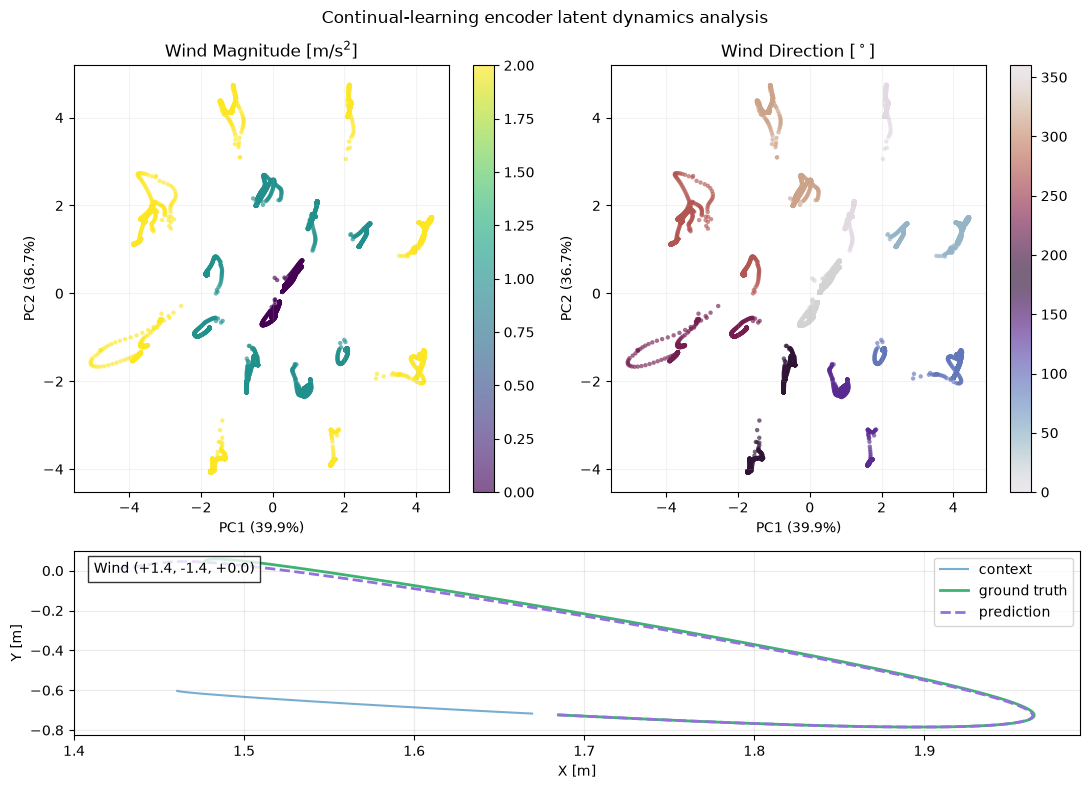

PCA variance explained by PC1 + PC2: 76.60%
Validation context windows encoded: 8,032
Aggregate latent mean/std: -4.765186e-02 / 1.074247e+00
Latent mean and standard deviation per dimension:
  z[00]: mean=+2.019767e-02, std=2.764615e-01
  z[01]: mean=-1.975464e-01, std=1.130939e+00
  z[02]: mean=-1.418178e-01, std=1.362670e+00
  z[03]: mean=-3.198549e-01, std=8.194954e-01
  z[04]: mean=-1.008401e-01, std=1.024580e+00
  z[05]: mean=-2.497506e-01, std=1.044235e+00
  z[06]: mean=-7.813013e-02, std=1.074785e+00
  z[07]: mean=+1.290470e-01, std=1.255894e+00
  z[08]: mean=+9.470533e-02, std=1.623747e+00
  z[09]: mean=+2.155176e-01, std=1.028889e+00
  z[10]: mean=+5.538657e-02, std=8.949631e-01
  z[11]: mean=+1.262627e-03, std=5.541291e-01
Representative rollout: 6, wind=[ 1.414214  -1.4142131  0.       ]


In [10]:
num_encoder_contexts_per_rollout = (
    validation_state_actions.shape[1] - context_length + 1
)
encoder_context_indices = (
    jnp.arange(num_encoder_contexts_per_rollout)[:, None]
    + jnp.arange(context_length)[None, :]
)
encoder_context_valid = validation_valid_transition[
    :, encoder_context_indices
].all(axis=-1)
all_encoder_contexts = validation_normalized_state_actions[
    :, encoder_context_indices
]
encoder_contexts = all_encoder_contexts[encoder_context_valid]
encoder_wind_grid = jnp.broadcast_to(
    validation_winds[:, None, :],
    (
        validation_num_rollouts,
        num_encoder_contexts_per_rollout,
        validation_winds.shape[-1],
    ),
)
encoder_winds = encoder_wind_grid[encoder_context_valid]

if encoder_contexts.shape[0] < 2:
    raise ValueError("At least two valid contexts are required for PCA")


def encode_contexts_in_batches(contexts):
    latent_chunks = []
    for start in range(0, contexts.shape[0], encoder_evaluation_batch_size):
        stop = min(
            start + encoder_evaluation_batch_size,
            contexts.shape[0],
        )
        latent_chunks.append(trajectory_encoder.apply(
            joint_params["encoder"], contexts[start:stop]
        ))
    return jnp.concatenate(latent_chunks, axis=0)


encoder_latents = encode_contexts_in_batches(encoder_contexts)
encoder_latents.block_until_ready()

plot_latents = np.asarray(jax.device_get(encoder_latents))
plot_winds = np.asarray(jax.device_get(encoder_winds))
latent_mean = plot_latents.mean(axis=0, keepdims=True)
centered_latents = plot_latents - latent_mean
_, singular_values, pca_directions = np.linalg.svd(
    centered_latents, full_matrices=False
)
latent_2d = centered_latents @ pca_directions[:2].T
pca_variance = singular_values**2
explained_variance = pca_variance / max(
    pca_variance.sum(), 1e-12
)

wind_magnitude = np.linalg.norm(plot_winds, axis=-1)
nonzero_wind = wind_magnitude > 1e-8
wind_direction = (
    np.degrees(np.arctan2(plot_winds[:, 1], plot_winds[:, 0]))
    % 360.0
)

desired_representative_wind = np.asarray([2.0, -2.0, 0.0])
host_open_loop_winds = np.asarray(jax.device_get(open_loop_winds))
representative_index = int(np.argmin(np.linalg.norm(
    host_open_loop_winds
    - desired_representative_wind[None, :],
    axis=-1,
)))
representative_rollout_id = int(
    open_loop_rollout_indices[representative_index]
)
representative_valid = np.asarray(jax.device_get(
    open_loop_valid_mask[representative_index]
))
representative_context_xy = np.asarray(jax.device_get(
    validation_quad_states.p[
        representative_rollout_id, :context_length + 1, :2
    ]
))
representative_true_xy = np.asarray(jax.device_get(
    open_loop_true_states.p[representative_index, :, :2]
))
representative_predicted_xy = np.asarray(jax.device_get(
    open_loop_predicted_states.p[representative_index, :, :2]
))
representative_wind = host_open_loop_winds[representative_index]

fig = plt.figure(figsize=(11, 8))
grid = fig.add_gridspec(2, 2, height_ratios=[3.0, 1.3])
magnitude_axis = fig.add_subplot(grid[0, 0])
direction_axis = fig.add_subplot(grid[0, 1])
trajectory_axis = fig.add_subplot(grid[1, :])

magnitude_points = magnitude_axis.scatter(
    latent_2d[:, 0],
    latent_2d[:, 1],
    c=wind_magnitude,
    cmap="viridis",
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
magnitude_axis.set_title(r"Wind Magnitude [$\mathrm{m/s^2}$]")
fig.colorbar(magnitude_points, ax=magnitude_axis)

direction_axis.scatter(
    latent_2d[~nonzero_wind, 0],
    latent_2d[~nonzero_wind, 1],
    color="lightgrey",
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
direction_points = direction_axis.scatter(
    latent_2d[nonzero_wind, 0],
    latent_2d[nonzero_wind, 1],
    c=wind_direction[nonzero_wind],
    cmap="twilight",
    vmin=0.0,
    vmax=360.0,
    s=10,
    alpha=0.65,
    linewidths=0.0,
)
direction_axis.set_title(r"Wind Direction [$^\circ$]")
fig.colorbar(direction_points, ax=direction_axis)

for axis in (magnitude_axis, direction_axis):
    axis.set_xlabel(f"PC1 ({100.0 * explained_variance[0]:.1f}%)")
    axis.set_ylabel(f"PC2 ({100.0 * explained_variance[1]:.1f}%)")
    axis.grid(True, alpha=0.15)

trajectory_axis.plot(
    representative_context_xy[:, 0],
    representative_context_xy[:, 1],
    color="C0",
    alpha=0.6,
    linewidth=1.5,
    label="context",
)
trajectory_axis.plot(
    representative_true_xy[representative_valid, 0],
    representative_true_xy[representative_valid, 1],
    color="mediumseagreen",
    linewidth=2.0,
    label="ground truth",
)
trajectory_axis.plot(
    representative_predicted_xy[representative_valid, 0],
    representative_predicted_xy[representative_valid, 1],
    color="mediumpurple",
    linestyle="--",
    linewidth=2.0,
    label="prediction",
)
trajectory_axis.text(
    0.02,
    0.88,
    f"Wind ({representative_wind[0]:+.1f}, "
    f"{representative_wind[1]:+.1f}, "
    f"{representative_wind[2]:+.1f})",
    transform=trajectory_axis.transAxes,
    bbox={"facecolor": "white", "alpha": 0.8},
)
trajectory_axis.set_xlabel("X [m]")
trajectory_axis.set_ylabel("Y [m]")
trajectory_axis.grid(True, alpha=0.25)
trajectory_axis.legend()

fig.suptitle("Continual-learning encoder latent dynamics analysis")
fig.tight_layout()
plt.show()

print(
    "PCA variance explained by PC1 + PC2: "
    f"{100.0 * explained_variance[:2].sum():.2f}%"
)
print(f"Validation context windows encoded: {plot_latents.shape[0]:,}")
print(
    f"Aggregate latent mean/std: "
    f"{plot_latents.mean():+.6e} / {plot_latents.std():.6e}"
)
print("Latent mean and standard deviation per dimension:")
for latent_index, (dimension_mean, dimension_std) in enumerate(zip(
    plot_latents.mean(axis=0), plot_latents.std(axis=0)
)):
    print(
        f"  z[{latent_index:02d}]: mean={dimension_mean:+.6e}, "
        f"std={dimension_std:.6e}"
    )
print(
    f"Representative rollout: {representative_rollout_id}, "
    f"wind={representative_wind}"
)
